In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.shape

(1025, 14)

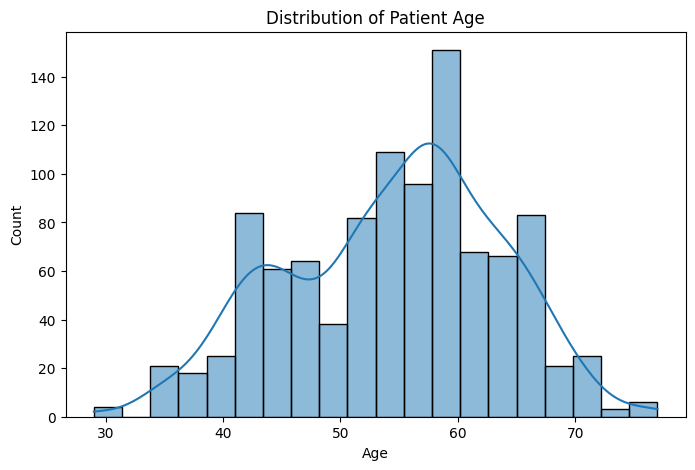

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

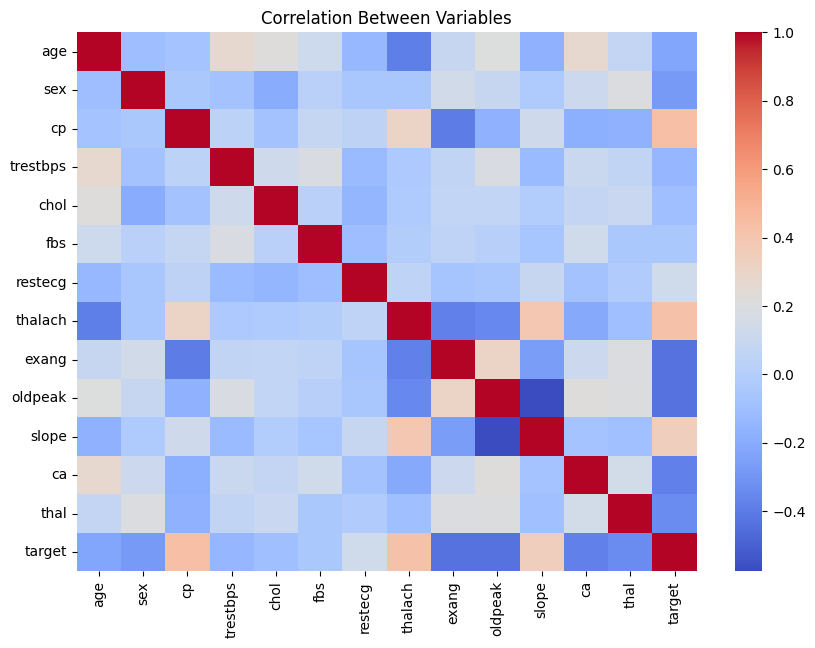

In [8]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Between Variables")
plt.show()

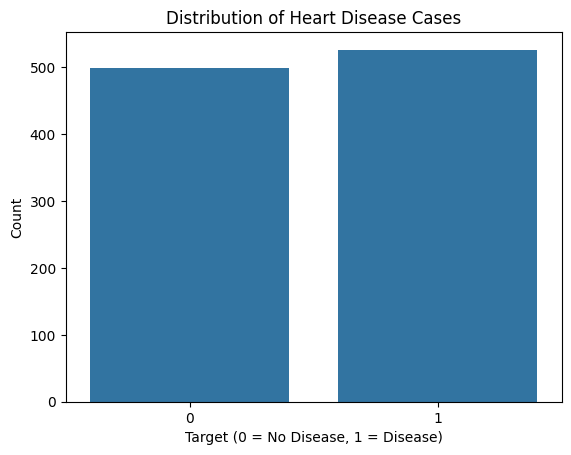

In [9]:
sns.countplot(x="target", data=df)
plt.title("Distribution of Heart Disease Cases")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

In [10]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [11]:
df.duplicated().sum()

np.int64(723)

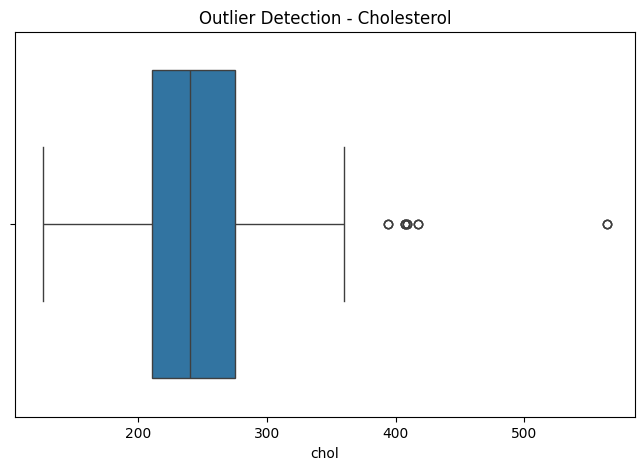

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["chol"])
plt.title("Outlier Detection - Cholesterol")
plt.show()

In [13]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [14]:
df_clean = df.copy()

In [17]:
df_encoded = pd.get_dummies(df_clean, columns=[
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"
], drop_first=True)

In [16]:
df_encoded.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,140,203,155,3.1,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,145,174,125,2.6,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,148,203,161,0.0,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,138,294,106,1.9,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

In [19]:
df_encoded[cols_to_scale].head()

,age,trestbps,chol,thalach,oldpeak
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888
1,-0.158157,0.479107,-0.833861,0.255968,1.727137
2,1.716595,0.764688,-1.396233,-1.048692,1.301417
3,0.724079,0.936037,-0.833861,0.516900,-0.912329
4,0.834359,0.364875,0.930822,-1.874977,0.705408


In [20]:
X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = model_lr.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8195121951219512


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[76 26]
 [11 92]]


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.75      0.80       102
           1       0.78      0.89      0.83       103

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205



In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
y_pred_rf = rf_model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [31]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[102   0]
 [  0 103]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00       103

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [33]:
import pandas as pd

importance = rf_model.feature_importances_
features = X.columns

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
4,oldpeak,0.120946
3,thalach,0.116000
21,thal_3,0.095136
20,thal_2,0.091893
2,chol,0.088077
0,age,0.083778
1,trestbps,0.071788
12,exang_1,0.045965
14,slope_2,0.040217
15,ca_1,0.033916


In [34]:
def validate_data(df):
    print("🔍 DATA VALIDATION REPORT")
    print("-" * 40)

    # 1. Missing values
    missing = df.isnull().sum().sum()
    print(f"Missing Values: {missing}")

    # 2. Duplicates
    duplicates = df.duplicated().sum()
    print(f"Duplicate Rows: {duplicates}")

    # 3. Data types
    print("\nData Types:")
    print(df.dtypes)

    # 4. Value range check (example for age)
    print("\nValue Range Check (Age):")
    print("Min Age:", df["age"].min())
    print("Max Age:", df["age"].max())

    print("-" * 40)
    print("Validation Completed ✅")

validate_data(df)

🔍 DATA VALIDATION REPORT
----------------------------------------
Missing Values: 0
Duplicate Rows: 723

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Value Range Check (Age):
Min Age: 29
Max Age: 77
----------------------------------------
Validation Completed ✅
